# Task 4b: 'Image/Video/Visual Evidence'

In this notebook, we are adding a new feature called **“Image/Video/Visual Evidence”** that searches for text that discusses any visual description. 

It is set to <span style="color:green">**True**</span> if we are able to successfully match the text to any visual description. And <span style="color:red">**False**</span> otherwise.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
haunted_places = pd.read_csv("../data/haunted_places.tsv", sep='\t')

In [4]:
# visual = ["cameras", "pictures", "photographs", "video", "movie", "news", "paint", "message", "see", "seen", "saw"]
haunted_places["Image/Video/Visual Evidence"] = haunted_places["description"].str.contains("|".join(visual), case=False, na=False)

NameError: name 'visual' is not defined

In [54]:
haunted_places.to_csv("../data/haunted_places.tsv", sep='\t', index=False)

# Visualizations
Let's take a look at some of the results. 

The first graph lets us examine the **Presence of Visual Evidence** within the entire dataset. Based on the graph, we have the following results: 
- Entries with Visual Evidence: 5478 (**49.8%**)
- Entries without Visual Evidence: 5514 (**50.2%**)

The second graph allows us to see the **Top 10 States with Most Haunted Places with Visual Evidence** with the number of of visual evidence per state next to it. 

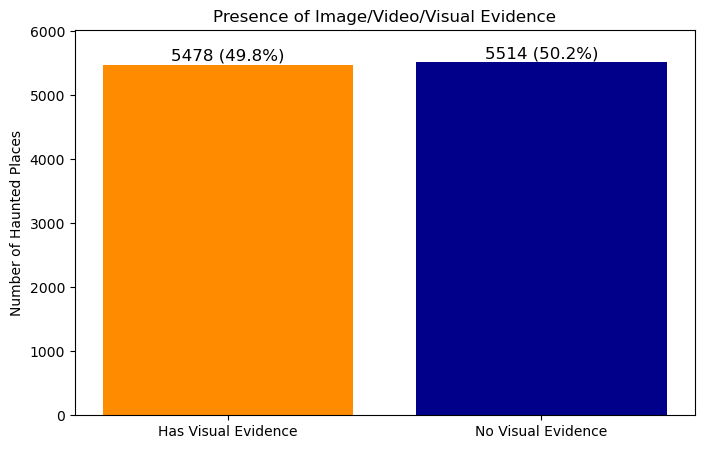

In [6]:
# Count occurrences of True and False
visual_counts = haunted_places['Image/Video/Visual Evidence'].value_counts()
total_entries = len(haunted_places)

# Reverse order to show "Has Visual Evidence" first
visual_counts = visual_counts[::-1]

# Create figure and plot
plt.figure(figsize=(8, 5))
bars = plt.bar(['Has Visual Evidence', 'No Visual Evidence'], visual_counts, color=['darkorange', 'darkblue'])

# Add text (count + percentage) on top of each bar
for bar, count in zip(bars, visual_counts):
    percentage = (count / total_entries) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,  # Adjust the +20 for spacing
             f'{count} ({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=12, color='black')  # va='bottom' places text above



# Labels and title
plt.ylabel('Number of Haunted Places')
plt.title('Presence of Image/Video/Visual Evidence')
plt.ylim(0, max(visual_counts) + 500)
plt.show()


/var/folders/z5/vfx1x7n1717bc2w84z8xwftw0000gn/T/ipykernel_5196/83741068.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='state', data=top10_states_visual, palette='Blues_r')


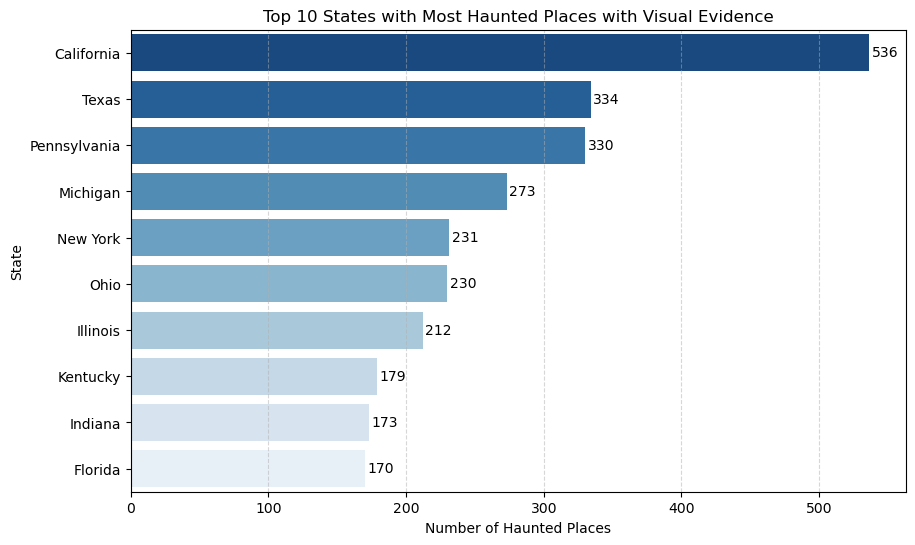

In [29]:
# Filter to just places with visual evidence
visual_df = haunted_places[haunted_places['Image/Video/Visual Evidence'] == True]

# Group by state and count
state_visual_counts = visual_df['state'].value_counts().reset_index()
state_visual_counts.columns = ['state', 'count']

# Only top 10 states
top10_states_visual = state_visual_counts.head(10)

# Plot bar chart (heatmap style)
plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='state', data=top10_states_visual, palette='Blues_r')

# Add count on bars
for index, row in top10_states_visual.iterrows():
    plt.text(row['count'] + 2, index, str(row['count']), color='black', va='center', fontsize=10)

# Labels and title
plt.title('Top 10 States with Most Haunted Places with Visual Evidence')
plt.xlabel('Number of Haunted Places')
plt.ylabel('State')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()
